In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/26_0_2_20170104023102422.jpg.chip.jpg
/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/22_1_1_20170112233644761.jpg.chip.jpg
/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/21_1_3_20170105003215901.jpg.chip.jpg
/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/28_0_0_20170117180555824.jpg.chip.jpg
/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/17_1_4_20170103222931966.jpg.chip.jpg
/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/44_0_3_20170119201022260.jpg.chip.jpg
/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/35_0_2_20170116182734834.jpg.chip.jpg
/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/76_0_0_20170104213515132.jpg.chip.jpg
/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/36_1_0_20170116165722892.jpg.chip.jpg
/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/34_0_3_20170119200815948.jpg.chip.jpg
/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/18_1_0_20170104022856102.jpg.chip.jpg
/kaggle/in

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/jangedoo/utkface-new


In [3]:
import os
import numpy as np
import pandas as pd
import tensorflow
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
age = []
gender = []
img_path = []
folder_path = '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace'
for file in os.listdir(folder_path):
    age.append(int(file.split('_')[0]))
    gender.append(int(file.split('_')[1]))
    img_path.append(file)

In [5]:
len(age)

23708

In [6]:
df = pd.DataFrame({'age' : age , 'gender': gender , 'img': img_path})

In [7]:
df.shape

(23708, 3)

In [8]:
df.head()

,age,gender,img
0,26,0,26_0_2_20170104023102422.jpg.chip.jpg
1,22,1,22_1_1_20170112233644761.jpg.chip.jpg
2,21,1,21_1_3_20170105003215901.jpg.chip.jpg
3,28,0,28_0_0_20170117180555824.jpg.chip.jpg
4,17,1,17_1_4_20170103222931966.jpg.chip.jpg


In [9]:
train_df = df.sample(frac = 1 , random_state = 0).iloc[:20000]
test_df = df.sample(frac = 1, random_state = 0).iloc[20000:]

In [10]:
train_df.shape

(20000, 3)

In [11]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                  rotation_range = 30,
                                  width_shift_range = 0.2,
                                  height_shift_range = 0.2,
                                  shear_range = 0.2,
                                  zoom_range = 0.2,
                                  horizontal_flip = True)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [12]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=folder_path,
    x_col='img',
    y_col=['age', 'gender'],
    target_size=(200, 200),
    class_mode='multi_output',
    batch_size=32
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=folder_path,
    x_col='img',
    y_col=['age', 'gender'],
    target_size=(200, 200),
    class_mode='multi_output',
    batch_size=32
)

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [13]:
from keras.models import Model
vggnet = VGG16(include_top = False , input_shape = (200,200,3))

I0000 00:00:1786952654.551735      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786952654.554871      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
vggnet.trainable = False

output = vggnet.layers[-1].output

flatten = Flatten()(output)

dense1 = Dense(512,activation = 'relu')(flatten)
dense2 = Dense(512,activation = 'relu')(flatten)

dense3 = Dense(512,activation = 'relu')(dense1)
dense4 = Dense(512,activation = 'relu')(dense2)

output1 = Dense(1,activation = 'linear', name = 'age')(dense3)
output2 = Dense(1,activation ='sigmoid',name = 'gender')(dense4)

In [15]:
model = Model(inputs =vggnet.input,outputs = [output1,output2])

In [16]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 200, 200,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 200, 200,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 100, 100,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 100, 100,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 100, 100,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 50, 50,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 50, 50,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 50, 50,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 50, 50,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 25, 25,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 25, 25,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 25, 25,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 25, 25,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 12, 12,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 12, 12,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 12, 12,    │  2,359,808 │ block5_conv1[0][

 Total params: 34,116,418 (130.14 MB)

 Trainable params: 19,401,730 (74.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

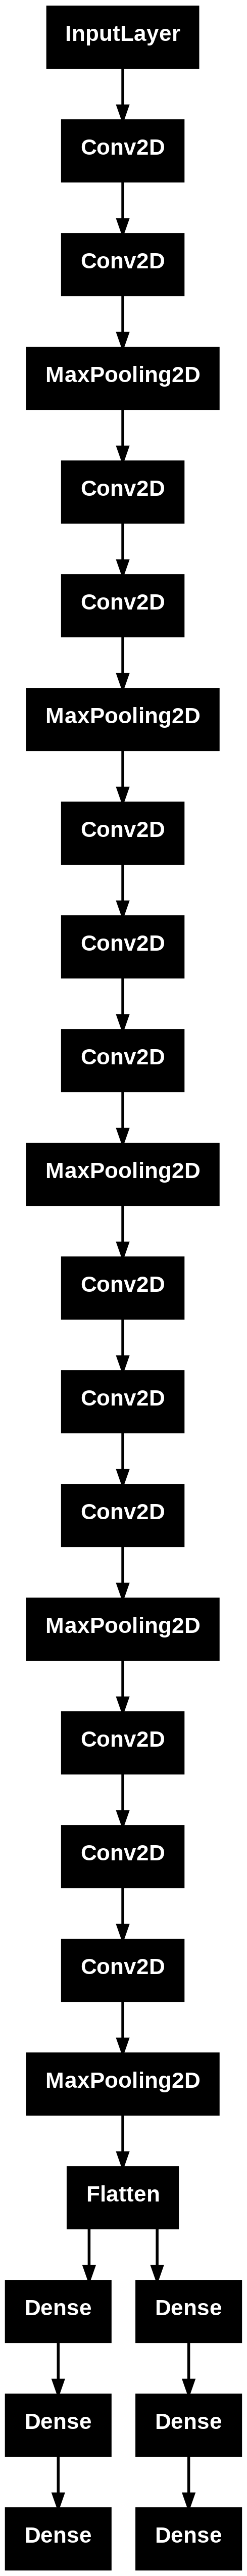

In [17]:
from keras.utils import plot_model
plot_model(model)

In [18]:
model.compile(optimizer = 'adam', loss = {'age': 'mae', 'gender': 'binary_crossentropy'}, metrics = {'age':'mae','gender':'accuracy'}, loss_weights = {'age': 1, 'gender': 99})

In [19]:
def generator_wrapper(generator):
    while True:
        x, y = next(generator)
        yield x, tuple(y)

train_gen = generator_wrapper(train_generator)
test_gen = generator_wrapper(test_generator)

In [20]:
history = model.fit(
    train_gen,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=test_gen,
    validation_steps=len(test_generator)
)

Epoch 1/10
  1/625 ━━━━━━━━━━━━━━━━━━━━ 2:42:20 16s/step - age_loss: 36.5769 - age_mae: 36.5769 - gender_accuracy: 0.4062 - gender_loss: 0.6967 - loss: 105.5489

I0000 00:00:1786952673.838335     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 417s 643ms/step - age_loss: 11.0373 - age_mae: 11.0373 - gender_accuracy: 0.7387 - gender_loss: 0.5299 - loss: 63.4955 - val_age_loss: 8.4736 - val_age_mae: 8.4736 - val_gender_accuracy: 0.8355 - val_gender_loss: 0.3655 - val_loss: 44.6192
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 255s 408ms/step - age_loss: 9.3362 - age_mae: 9.3362 - gender_accuracy: 0.7891 - gender_loss: 0.4433 - loss: 53.2232 - val_age_loss: 8.1040 - val_age_mae: 8.1024 - val_gender_accuracy: 0.8482 - val_gender_loss: 0.3383 - val_loss: 41.5864
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 251s 402ms/step - age_loss: 9.0673 - age_mae: 9.0673 - gender_accuracy: 0.8082 - gender_loss: 0.4117 - loss: 49.8275 - val_age_loss: 8.0444 - val_age_mae: 8.0444 - val_gender_accuracy: 0.8125 - val_gender_loss: 0.3955 - val_loss: 47.1974
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 245s 393ms/step - age_loss: 8.8103 - age_mae: 8.8103 - gender_accuracy: 0.8128 - gender_loss: 0.3999 - loss: 48.3970 - val_age_loss: 7.

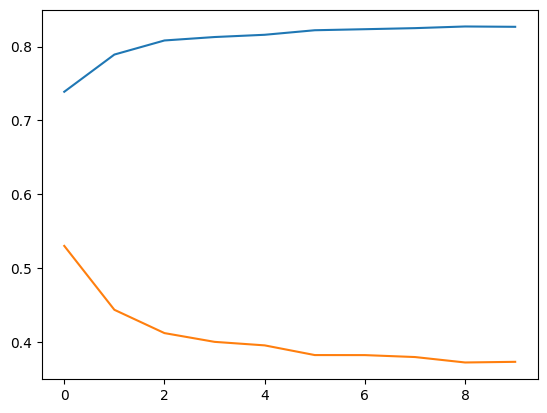

In [23]:
import matplotlib.pyplot as plt
plt.plot(history.history['gender_accuracy'])
plt.plot(history.history['gender_loss'])